<a href="https://colab.research.google.com/github/karywnl/kaggle/blob/main/matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
from google.colab import drive

drive.mount("/content/drive")
os.environ["KAGGLE_CONFIG_DIR"] = "/content/drive/MyDrive/Kaggle"

!chmod 600 "/content/drive/MyDrive/Kaggle/kaggle.json"

Mounted at /content/drive


In [3]:
!kaggle datasets download -d 'alexisbcook/data-for-datavis'
!unzip data-for-datavis.zip

Dataset URL: https://www.kaggle.com/datasets/alexisbcook/data-for-datavis
License(s): unknown
  0% 0.00/142k [00:00<?, ?B/s]
100% 142k/142k [00:00<00:00, 450MB/s]
Archive:  data-for-datavis.zip
  inflating: cancer.csv              
  inflating: cancer_b.csv            
  inflating: cancer_m.csv            
  inflating: candy.csv               
  inflating: fifa.csv                
  inflating: flight_delays.csv       
  inflating: ign_scores.csv          
  inflating: insurance.csv           
  inflating: iris.csv                
  inflating: iris_setosa.csv         
  inflating: iris_versicolor.csv     
  inflating: iris_virginica.csv      
  inflating: museum_visitors.csv     
  inflating: spotify.csv             


In [4]:
fifa_data = pd.read_csv('fifa.csv')
fifa_data.head()

,Date,ARG,BRA,ESP,FRA,GER,ITA
0,1993-08-08,5.0,8.0,13.0,12.0,1.0,2.0
1,1993-09-23,12.0,1.0,14.0,7.0,5.0,2.0
2,1993-10-22,9.0,1.0,7.0,14.0,4.0,3.0
3,1993-11-19,9.0,4.0,7.0,15.0,3.0,1.0
4,1993-12-23,8.0,3.0,5.0,15.0,1.0,2.0


In [5]:
spotify_data = pd.read_csv("spotify.csv")

In [6]:
spotify_data.head()

,Date,Shape of You,Despacito,Something Just Like This,HUMBLE.,Unforgettable
0,2017-01-06,12287078,NaN,NaN,NaN,NaN
1,2017-01-07,13190270,NaN,NaN,NaN,NaN
2,2017-01-08,13099919,NaN,NaN,NaN,NaN
3,2017-01-09,14506351,NaN,NaN,NaN,NaN
4,2017-01-10,14275628,NaN,NaN,NaN,NaN


Line Plot in seaborn is more abstract it by default does everything unless you specifically asked to customize.

<Axes: >

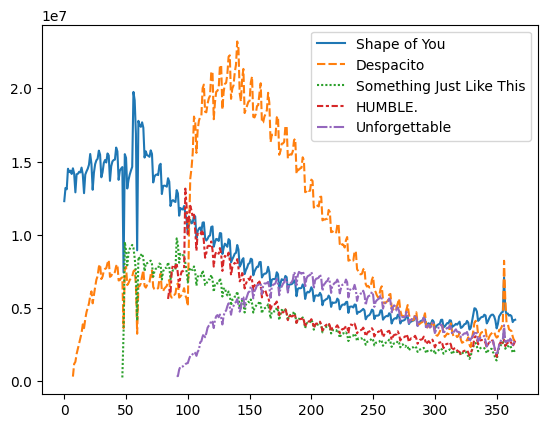

In [7]:
sns.lineplot(data=spotify_data)

In [8]:
museum_data = pd.read_csv("museum_visitors.csv", index_col="Date", parse_dates=True)
museum_data.head()

,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
Date,,,,
2014-01-01,24778,4486,1581,6602
2014-02-01,18976,4172,1785,5029
2014-03-01,25231,7082,3229,8129
2014-04-01,26989,6756,2129,2824
2014-05-01,36883,10858,3676,10694


In [9]:
museum_data[museum_data.index == "2018-07-01"]["Chinese American Museum"].iloc[0]

np.int64(2620)

In [10]:
museum_data[museum_data.index == "2018-08-01"]["Avila Adobe"].iloc[0] - museum_data[museum_data.index == "2018-08-01"]["Firehouse Museum"].iloc[0]

np.int64(15949)

# **Bar charts and Heatmaps**

In [11]:
ign_data = pd.read_csv("ign_scores.csv", index_col="Platform")
ign_data.head()

,Action,"Action, Adventure",Adventure,Fighting,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
Dreamcast,6.882857,7.511111,6.281818,8.200000,8.340000,8.088889,7.700000,7.042500,7.616667,7.628571,7.272222,6.433333
Game Boy Advance,6.373077,7.507692,6.057143,6.226316,6.970588,6.532143,7.542857,6.657143,6.444444,6.928571,6.694444,7.175000
Game Boy Color,6.272727,8.166667,5.307692,4.500000,6.352941,6.583333,7.285714,5.897436,4.500000,5.900000,5.790698,7.400000
GameCube,6.532584,7.608333,6.753846,7.422222,6.665714,6.133333,7.890909,6.852632,6.981818,8.028571,7.481319,7.116667
Nintendo 3DS,6.670833,7.481818,7.414286,6.614286,7.503448,8.000000,7.719231,6.900000,7.033333,7.700000,6.388889,7.900000


In [ ]:
ign_data.index

Index(['Dreamcast', 'Game Boy Advance', 'Game Boy Color', 'GameCube',
       'Nintendo 3DS', 'Nintendo 64', 'Nintendo DS', 'Nintendo DSi', 'PC',
       'PlayStation', 'PlayStation 2', 'PlayStation 3', 'PlayStation 4',
       'PlayStation Portable', 'PlayStation Vita', 'Wii', 'Wireless', 'Xbox',
       'Xbox 360', 'Xbox One', 'iPhone'],
      dtype='object', name='Platform')

1. What is the highest average score received by PC games for any genre?

In [12]:
ign_data.loc["PC"].max()

7.759930313588847

On the Playstation Vita platform, which genre has the lowest average score? Please provide the name of the column, and put your answer in single quotes (e.g., 'Action', 'Adventure', 'Fighting', etc.)

In [13]:
ign_data.loc["PlayStation Vita"].idxmin()

'Simulation'

Create a bar chart that shows the average score for racing games, for each platform. Your chart should have one bar for each platform.

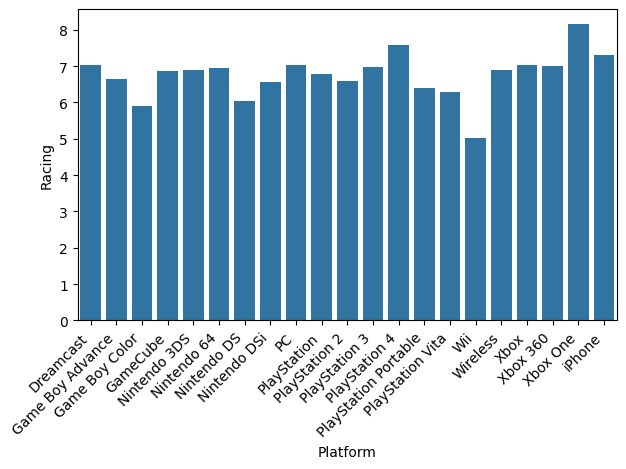

In [14]:
sns.barplot(x=ign_data.index, y=ign_data["Racing"])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


Use the data to create a heatmap of average score by genre and platform.

<Axes: ylabel='Platform'>

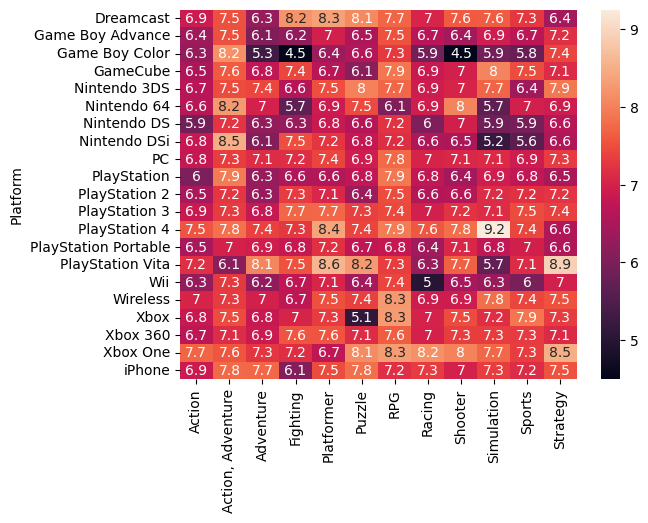

In [15]:
sns.heatmap(data=ign_data, annot=True)

# **Scatter Plots**

In [16]:
candy_data = pd.read_csv("candy.csv", index_col="id")
candy_data.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
id,,,,,,,,,,,,,
0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547
